1. DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
import warnings

2. Log path loss model

In [ ]:
import numpy as np
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error

# TODO: fix gateway position, recalculate distance and make sure it it measured from 1355 and center. 

# Do it here for the small
df = pd.read_csv("outputs/tests_gh_25_06/clean_data.csv")

# Gateway assumed at origin (0, 0) on the walking path
x_gateway = 3.3
y_gateway = 0.0
df['distance'] = np.sqrt((df['x_m'] - x_gateway)**2 + (df['y_m'] - y_gateway)**2)

# Row crossings: 1.1 m between rows
df['row_crossings'] = (df['y_m'].abs() / 1.65).round().astype(int)

# Grid label needed downstream (Moran's I aggregation, grouped CV, GPR)
df['grid_label'] = df['structure_id'] + '_G' + df['manual_group'].astype(str)

print('Row crossings by y_m:')
print(df.groupby('y_m')['row_crossings'].first())

valid = df.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

log_d = np.log10(valid['distance'].values)
rssi = valid['rssi'].values
crossings = valid['row_crossings'].values

# --- Model 1: baseline, no row_crossings ---
X_pl_base = np.column_stack([np.ones(len(valid)), log_d])
coeffs_base, _, _, _ = lstsq(X_pl_base, rssi, rcond=None)
A_g_base, n_log10_base = coeffs_base
pred_base = X_pl_base @ coeffs_base
rmse_base = np.sqrt(mean_squared_error(rssi, pred_base))

# --- Model 2: with row_crossings (currently the retained/reported model) ---
X_pl_full = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_full, _, _, _ = lstsq(X_pl_full, rssi, rcond=None)
A_g_full, n_log10_full, beta = coeffs_full
pred_full = X_pl_full @ coeffs_full
rmse_full = np.sqrt(mean_squared_error(rssi, pred_full))

# Store pl_pred / pl_residual on valid using the FULL model — these are
# consumed downstream by Moran's I and GPR input prep
valid['pl_pred'] = pred_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

print('\n=== Path-Loss Model Comparison ===')
print('Baseline (no row_crossings):')
print(f'  A_g (intercept)     : {A_g_base:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_base/10:.3f}')
print(f'  RMSE                : {rmse_base:.2f} dBm')
print()
print('With row_crossings term:')
print(f'  A_g (intercept)     : {A_g_full:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_full/10:.3f}')
print(f'  β   (row penalty)   : {beta:.2f} dBm per row crossed')
print(f'  RMSE                : {rmse_full:.2f} dBm')
print()
print(f'RMSE improvement: {rmse_base - rmse_full:.3f} dBm')

# Multicollinearity sanity check between log_d and crossings
corr = np.corrcoef(log_d, crossings)[0, 1]
print(f'\nCorrelation(log10(distance), row_crossings): {corr:.3f}')
print('(if this is very high, β may still be poorly estimated despite')
print(' technically being identifiable)')

Row crossings by y_m:
y_m
-25.3      15
-20.9      13
-16.5      10
-12.1       7
-7.7        5
-5.5        3
-3.3        2
-1.1        1
 1.1        1
 3.3        2
 5.5        3
 14.3       9
 17.6      11
 23.1      14
 29.7      18
 34.1      21
 39.6      24
 45.1      27
 50.6      31
 61.6      37
 71.5      43
 83.6      51
 85.8      52
 94.6      57
 105.6     64
 116.6     71
 126.5     77
 127.6     77
 138.6     84
 147.4     89
 152.9     93
 156.2     95
 158.4     96
 160.6     97
 162.8     99
 165.0    100
Name: row_crossings, dtype: int64

=== Path-Loss Model Comparison ===
Baseline (no row_crossings):
  A_g (intercept)     : -20.16 dBm
  n   (path-loss exp) : 3.927
  RMSE                : 5.68 dBm

With row_crossings term:
  A_g (intercept)     : -21.53 dBm
  n   (path-loss exp) : 3.801
  β   (row penalty)   : -0.05 dBm per row crossed
  RMSE                : 5.58 dBm

RMSE improvement: 0.107 dBm

Correlation(log10(distance), row_crossings): 0.355
(if this is very h

In [ ]:
print('=== Row-Crossings Contribution to Physical Model ===')
print(f'Baseline (distance only)      RMSE: {rmse_base:.3f} dBm')
print(f'With row_crossings term       RMSE: {rmse_full:.3f} dBm')
print(f'Improvement from row_crossings    : {rmse_base - rmse_full:.3f} dBm '
      f'({100*(rmse_base - rmse_full)/rmse_base:.1f}%)')
print()
print(f'β (row penalty)                   : {beta:.3f} dBm per row crossed')

=== Row-Crossings Contribution to Physical Model ===
Baseline (distance only)      RMSE: 5.684 dBm
With row_crossings term       RMSE: 5.577 dBm
Improvement from row_crossings    : 0.107 dBm (1.9%)

β (row penalty)                   : -0.049 dBm per row crossed


In [ ]:
print('Unique y_m values and corresponding row_crossings:')
print(df.groupby('y_m')['row_crossings'].first().to_string())
print()
print(f'Unique row_crossings values: {sorted(df["row_crossings"].unique())}')
print(f'Row_crossings range: {df["row_crossings"].min()} to {df["row_crossings"].max()}')
print()
# Sanity check: y_m values should be roughly evenly spaced multiples of 1.1
unique_abs_y = sorted(df['y_m'].abs().unique())
print(f'Unique |y_m| values (first 10): {unique_abs_y[:10]}')
print(f'Differences between consecutive |y_m| values (should be ~1.1 or multiples): '
      f'{np.diff(unique_abs_y[:10]).round(2)}')

Unique y_m values and corresponding row_crossings:
y_m
-25.3      15
-20.9      13
-16.5      10
-12.1       7
-7.7        5
-5.5        3
-3.3        2
-1.1        1
 1.1        1
 3.3        2
 5.5        3
 14.3       9
 17.6      11
 23.1      14
 29.7      18
 34.1      21
 39.6      24
 45.1      27
 50.6      31
 61.6      37
 71.5      43
 83.6      51
 85.8      52
 94.6      57
 105.6     64
 116.6     71
 126.5     77
 127.6     77
 138.6     84
 147.4     89
 152.9     93
 156.2     95
 158.4     96
 160.6     97
 162.8     99
 165.0    100

Unique row_crossings values: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(31), np.int64(37), np.int64(43), np.int64(51), np.int64(52), np.int64(57), np.int64(64), np.int64(71), np.int64(77), np.int64(84), np.int64(89), np.int64(93), np.int64(95), np.int64(96), np.int64(9

In [ ]:
import joblib
joblib.dump(coeffs_full, 'pathloss_coeffs_full_dataset.pkl')
joblib.dump({'A_g_full': A_g_full, 'n_full': -n_log10_full/10, 'beta': beta, 'rmse_full': rmse_full},
            'pathloss_summary_full_dataset.pkl')

['pathloss_summary_full_dataset.pkl']

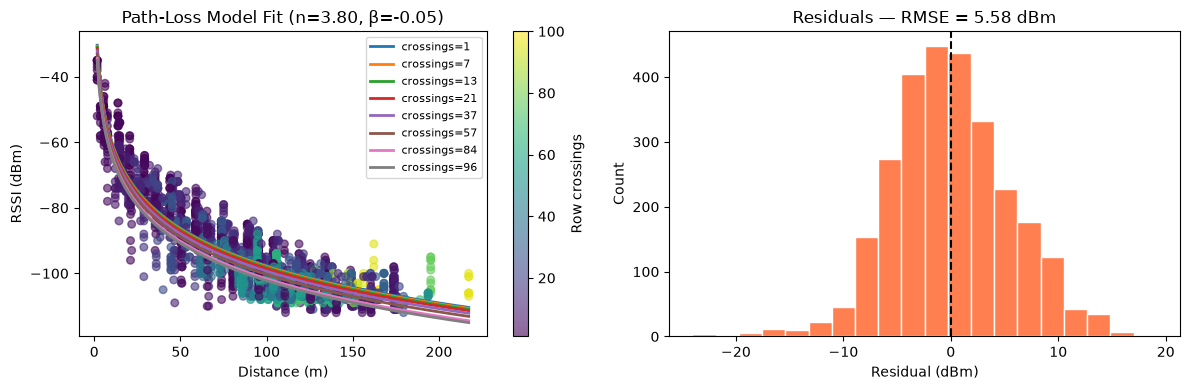

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute pl_pred / pl_residual on valid using the FULL model
valid['pl_pred'] = X_pl_full @ coeffs_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

# Scatter colored by row_crossings so the plot reflects that pl_pred
# now depends on crossings too, not just distance
scatter = axes[0].scatter(
    valid['distance'], valid['rssi'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

# Plot fit lines for a REPRESENTATIVE SUBSET of crossing levels (capped, so
# the legend stays readable with many more crossing levels in the full dataset)
crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for c in crossing_levels:
    pl_line = A_g_full + n_log10_full * np.log10(d_range) + beta * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_title(f'Path-Loss Model Fit (n={-n_log10_full/10:.2f}, β={beta:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['pl_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals — RMSE = {rmse_full:.2f} dBm')

plt.tight_layout()
plt.savefig('pathloss_fit.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I. 

Running Moran's I on 410 grid cell medians (not 2762 individual packets)
=== Moran's I Test ===
  Moran's I : 0.3566
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: proceed to GPR residual model.


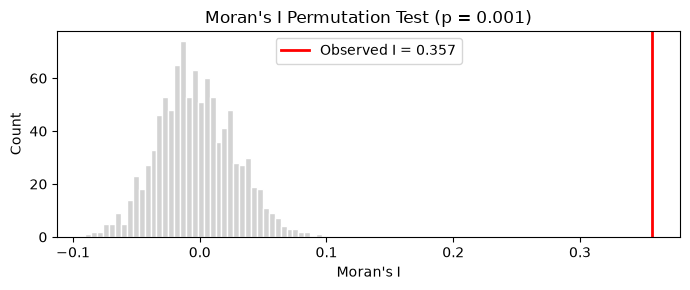

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran

# Aggregate to one mean residual per grid cell before testing.
# Repeated packets at the same location are not independent spatial
# units — using them directly would inflate the effective N and bias
# the test (same pseudo-replication issue as the OLS/row_crossings check).
cell_medians = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('pl_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('pl_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians)} grid cell medians (not {len(valid)} individual packets)")

coords_arr = cell_medians[['x_m', 'y_m']].values
residuals_arr = cell_medians['median_residual'].values

# k-NN spatial weights: each cell's "neighbors" are its k nearest cells
k = min(5, len(cell_medians) - 1)  # lower this, or switch to a distance-band
                                   # weight matrix, if results are borderline
w = KNN.from_array(coords_arr, k=k)
w.transform = 'r'   # row-standardize weights (esda's Moran expects this)

np.random.seed(42)
moran = Moran(residuals_arr, w, permutations=999)

print("=== Moran's I Test ===")
print(f"  Moran's I : {moran.I:.4f}")
print(f"  p-value   : {moran.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran.p_sim < 0.05 and moran.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model.')
    USE_GPR = True
else:
    print('No significant spatial autocorrelation: the path-loss model is sufficient.')
    USE_GPR = False

# Visualization: observed I against the permutation null distribution
plt.figure(figsize=(7, 3))
plt.hist(moran.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran.I, color='red', lw=2, label=f'Observed I = {moran.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test (p = {moran.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i.png', dpi=150, bbox_inches='tight')
plt.show()

2. GPR


2.1 Set-up

In [ ]:
# INPUT + TARGET, format based on the data
X_gpr = valid[['x_m', 'y_m']].values.copy()
y_gpr = valid['pl_residual'].values.copy()

print(f'GPR input set: {X_gpr.shape[0]} packets, {X_gpr.shape[1]} input dims (x_m, y_m)')
print(f'Residual range : {y_gpr.min():.2f} to {y_gpr.max():.2f} dBm')
print(f'Residual mean  : {y_gpr.mean():.2f} dBm')

# Add tiny jitter to duplicate/near-duplicate coordinates so the kernel
# matrix K stays invertible (multiple packets logged at the same grid cell)
np.random.seed(42)
X_gpr += np.random.normal(0, 0.01, X_gpr.shape)

# Sanity check: how many exact coordinate duplicates existed before jitter
n_unique_coords = len(valid[['x_m', 'y_m']].drop_duplicates())
print(f'\nUnique (x_m, y_m) pairs: {n_unique_coords} / {len(valid)} packets')
print(f'Unique grid cells (grid_label): {valid["grid_label"].nunique()}')


GPR input set: 2762 packets, 2 input dims (x_m, y_m)
Residual range : -24.04 to 19.16 dBm
Residual mean  : 0.00 dBm

Unique (x_m, y_m) pairs: 410 / 2762 packets
Unique grid cells (grid_label): 410


2.2 Scale

In [ ]:
# Scale coordinates to zero mean, unit variance
# GPR is sensitive to the scale of inputs, without this the  hyperparameter optimisation might fail/converge poorly
scaler = StandardScaler()
X_gpr_scaled = scaler.fit_transform(X_gpr)

print('Coordinate scaling:')
print(f'  X mean: {scaler.mean_[0]:.2f} m  std: {scaler.scale_[0]:.2f} m')
print(f'  Y mean: {scaler.mean_[1]:.2f} m  std: {scaler.scale_[1]:.2f} m')

Coordinate scaling:
  X mean: 15.76 m  std: 89.25 m
  Y mean: 27.80 m  std: 44.69 m


In [ ]:
# Verify all dependencies exist before running the full block
required_vars = ['length_scale_bounds', 'gpr', 'y_gpr', 'X_gpr_scaled', 'valid']
for v in required_vars:
    exists = v in dir()
    print(f'{v}: {"OK" if exists else "MISSING"}')

length_scale_bounds: MISSING
gpr: MISSING
y_gpr: OK
X_gpr_scaled: OK
valid: OK


In [ ]:
x_scaled_range = X_gpr_scaled[:, 0].max() - X_gpr_scaled[:, 0].min()
y_scaled_range = X_gpr_scaled[:, 1].max() - X_gpr_scaled[:, 1].min()
length_scale_bounds = [(0.01, x_scaled_range), (0.01, y_scaled_range)]
print(f'length_scale_bounds: {length_scale_bounds}')

length_scale_bounds: [(0.01, np.float64(3.742606015457694)), (0.01, np.float64(4.259015526781241))]


In [ ]:
import joblib
gpr = joblib.load('gpr_model_full_dataset.pkl')
print('Baseline gpr reloaded.')

Baseline gpr reloaded.


d:\Users\user\Documents\GatewayPlacement\.conda\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# Verify all dependencies exist before running the full block
required_vars = ['length_scale_bounds', 'gpr', 'y_gpr', 'X_gpr_scaled', 'valid']
for v in required_vars:
    exists = v in dir()
    print(f'{v}: {"OK" if exists else "MISSING"}')

length_scale_bounds: OK
gpr: OK
y_gpr: OK
X_gpr_scaled: OK
valid: OK


2.3 Kernel with heteroscedastic noise

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# --- Estimate per-cell noise variance from within-cell packet spread ---
cell_noise_var = valid.groupby('grid_label')['pl_residual'].var()
cell_counts = valid.groupby('grid_label')['pl_residual'].count()

min_reliable_n = 3
reliable_cells = cell_counts[cell_counts >= min_reliable_n].index
n_reliable = len(reliable_cells)
n_total_cells = valid['grid_label'].nunique()

print(f'Cells with >= {min_reliable_n} packets: {n_reliable} / {n_total_cells}')

global_median_var = cell_noise_var[reliable_cells].median()
print(f'Global median cell variance (fallback): {global_median_var:.3f} dB²')

valid['cell_noise_var'] = valid['grid_label'].map(cell_noise_var)
valid.loc[~valid['grid_label'].isin(reliable_cells), 'cell_noise_var'] = global_median_var
valid['cell_noise_var'] = valid['cell_noise_var'].fillna(global_median_var)

print(f'Per-point noise variance range: {valid["cell_noise_var"].min():.3f} to {valid["cell_noise_var"].max():.3f} dB²')

# --- Convert to standardized alpha (normalize_y divides by y_gpr.std(), so
# alpha must be divided by y_gpr.var() to live in the same standardized space) ---
alpha_per_point = valid['cell_noise_var'].values / y_gpr.var()

# --- Fit heteroscedastic model: no WhiteKernel, alpha carries all the noise ---
kernel_hetero = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero = GaussianProcessRegressor(
    kernel=kernel_hetero,
    alpha=alpha_per_point,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero.fit(X_gpr_scaled, y_gpr)

lml_hetero = gpr_hetero.log_marginal_likelihood(gpr_hetero.kernel_.theta)
lml_baseline = gpr.log_marginal_likelihood(gpr.kernel_.theta)

print(f'\n=== Quick LML Comparison ===')
print(f'Baseline (global WhiteKernel) LML : {lml_baseline:.2f}')
print(f'Heteroscedastic (per-cell alpha) LML: {lml_hetero:.2f}')
print(f'\nFitted kernel: {gpr_hetero.kernel_}')

Cells with >= 3 packets: 377 / 410
Global median cell variance (fallback): 5.611 dB²
Per-point noise variance range: 0.000 to 104.528 dB²

=== Quick LML Comparison ===
Baseline (global WhiteKernel) LML : -1875.64
Heteroscedastic (per-cell alpha) LML: -1989.25

Fitted kernel: 0.8**2 * Matern(length_scale=[0.161, 0.111], nu=0.5)


In [ ]:
# Find the noisiest cells and inspect them directly
cell_std_sorted = cell_noise_var[reliable_cells].apply(np.sqrt).sort_values(ascending=False)
print("Noisiest cells (std, dB):")
print(cell_std_sorted.head(10))
print()

# Look at the raw packets in the single worst cell
worst_cell = cell_std_sorted.index[0]
worst_cell_data = valid[valid['grid_label'] == worst_cell][['x_m', 'y_m', 'rssi', 'pl_residual', 'time_local']]
print(f"Worst cell: {worst_cell}")
print(worst_cell_data.sort_values('time_local') if 'time_local' in worst_cell_data else worst_cell_data)

Noisiest cells (std, dB):
grid_label
R1181_G1     10.223883
R1181_G5     10.084642
R1348_G12     9.320504
R1181_G2      9.086620
R1183_G2      8.961027
R1451_G12     8.760990
R1150_G1      8.664102
R1354_G2      8.513295
R1340_G4      8.399074
R1336_G7      7.949843
Name: pl_residual, dtype: float64

Worst cell: R1181_G1
      x_m  y_m  rssi  pl_residual                 time_local
1102  4.0  5.5 -51.0     5.573133  2026-06-29 15:03:26+02:00
1103  4.0  5.5 -52.0     4.573133  2026-06-29 15:03:28+02:00
1104  4.0  5.5 -52.0     4.573133  2026-06-29 15:03:30+02:00
1105  4.0  5.5 -53.0     3.573133  2026-06-29 15:03:36+02:00
1106  4.0  5.5 -63.0    -6.426867  2026-06-29 15:03:40+02:00
1107  4.0  5.5 -74.0   -17.426867  2026-06-29 15:03:45+02:00
1108  4.0  5.5 -68.0   -11.426867  2026-06-29 15:03:48+02:00
1109  4.0  5.5 -62.0    -5.426867  2026-06-29 15:03:49+02:00
1110  4.0  5.5 -78.0   -21.426867  2026-06-29 15:03:51+02:00


In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
""" 
groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

fold_rmse_hetero = []
for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],   # per-point alpha must be sliced per fold too
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
    y_pred = gp_cv.predict(X_gpr_scaled[test_idx])
    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], y_pred)))

print(f'Heteroscedastic CV RMSE: {np.mean(fold_rmse_hetero):.3f} ± {np.std(fold_rmse_hetero):.3f} dBm')
print(f'Baseline CV RMSE       : 5.96 dBm') """

In [ ]:
import joblib
joblib.dump(gpr_hetero, 'gpr_hetero_final_candidate.pkl')
joblib.dump(alpha_per_point, 'alpha_hetero_final.pkl')
print('Saved: gpr_hetero_final_candidate.pkl, alpha_hetero_final.pkl')

Saved: gpr_hetero_final_candidate.pkl, alpha_hetero_final.pkl


In [ ]:
import numpy as np
import pandas as pd

# generation of predictions

x_min, x_max = -165.3, 158.7
y_min, y_max = -92.4, 198.0
grid_res = 2.0

x_grid = np.arange(x_min, x_max + grid_res, grid_res)
y_grid = np.arange(y_min, y_max + grid_res, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel()})
print(f'Prediction grid: {len(grid_df)} points ({len(x_grid)} x {len(y_grid)})')

grid_df['distance'] = np.sqrt(grid_df['x_m']**2 + grid_df['y_m']**2)
grid_df.loc[grid_df['distance'] == 0, 'distance'] = 0.01

grid_df['row_crossings'] = (grid_df['y_m'].abs() / 1.1).round().astype(int)

log_d_grid = np.log10(grid_df['distance'].values)
crossings_grid = grid_df['row_crossings'].values
X_pl_grid = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['pl_pred'] = X_pl_grid @ coeffs_full

Prediction grid: 23961 points (163 x 147)


In [ ]:
for v in ['coeffs_full', 'scaler', 'gpr_hetero']:
    print(f'{v}: {"OK" if v in dir() else "MISSING"}')

coeffs_full: OK
scaler: OK
gpr_hetero: OK


In [ ]:
X_grid_coords = grid_df[['x_m', 'y_m']].values
X_grid_scaled = scaler.transform(X_grid_coords)

gpr_mean, gpr_std = gpr_hetero.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred'] = gpr_mean
grid_df['gpr_std'] = gpr_std

grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'gpr_std']].describe())

                x_m           y_m       pl_pred  gpr_residual_pred  \
count  23961.000000  23961.000000  23961.000000       23961.000000   
mean      -3.300000     53.600000   -101.455031          -0.113591   
std       94.108287     84.870297      9.330797           2.387843   
min     -165.300000    -92.400000   -116.803429         -12.039892   
25%      -85.300000    -20.400000   -107.952046          -0.996792   
50%       -3.300000     53.600000   -103.152848          -0.000096   
75%       78.700000    127.600000    -96.858796           0.233295   
max      158.700000    199.600000    -23.696198          13.136559   

          rssi_pred       gpr_std  
count  23961.000000  23961.000000  
mean    -101.568621      4.422911  
std        9.775153      0.745300  
min     -116.803408      0.973976  
25%     -107.676895      3.965460  
50%     -104.524613      4.846096  
75%      -97.203326      5.008181  
max      -31.925434      5.008295  


CROSS VALIDATION FOR THE BEST MODEL ONLY NOW

Heatmap

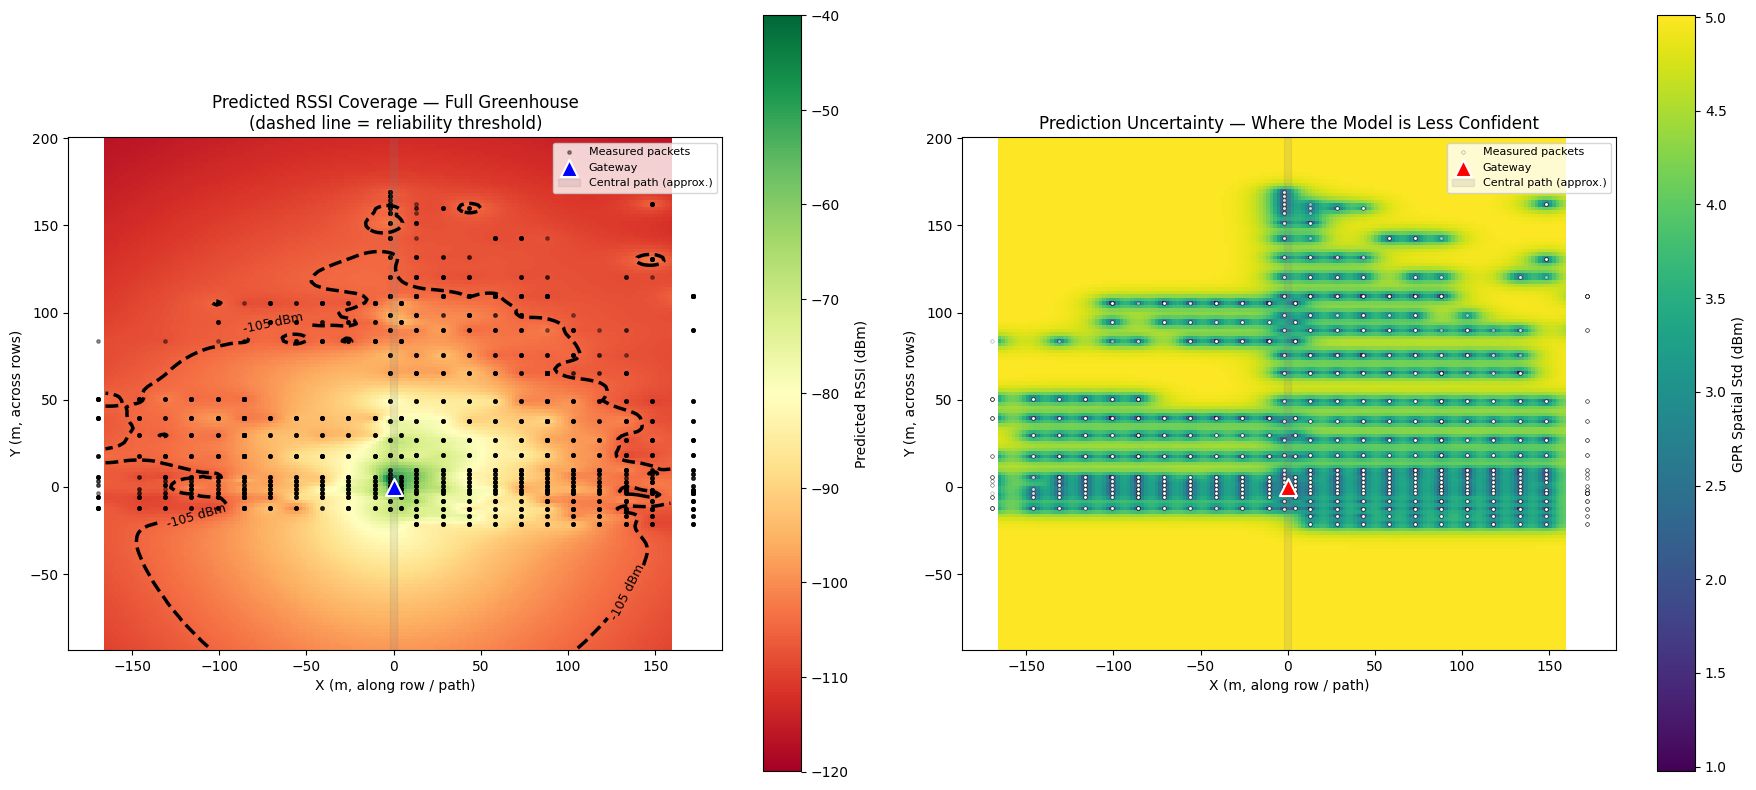

In [ ]:
import matplotlib.pyplot as plt

rssi_grid = grid_df['rssi_pred'].values.reshape(xx.shape)
std_grid = grid_df['gpr_std'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_dbm = -105  # adjust to your target SF's sensitivity + desired margin

# --- Panel 1: Predicted RSSI coverage ---
im1 = axes[0].pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto',
                           vmin=-120, vmax=-40)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted RSSI (dBm)')

contour1 = axes[0].contour(xx, yy, rssi_grid, levels=[threshold_dbm],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_dbm} dBm', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted RSSI Coverage — Full Greenhouse\n(dashed line = reliability threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: Prediction uncertainty (unchanged, contour not meaningful here) ---
im2 = axes[1].pcolormesh(xx, yy, std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dBm)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SNR — Path-Loss Model

Same log-distance + row-crossings regression as the RSSI path-loss step above, fit on SNR instead. Produces `coeffs_snr`, `valid['snr_pred']`, `valid['snr_residual']` — consumed downstream by the SNR-specific Moran's I and GPR steps, kept fully separate from the RSSI residual chain.

In [ ]:
snr = valid['snr'].values

X_pl_snr = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_snr, _, _, _ = lstsq(X_pl_snr, snr, rcond=None)
A_g_snr, n_log10_snr, beta_snr = coeffs_snr
pred_snr = X_pl_snr @ coeffs_snr
rmse_snr = np.sqrt(mean_squared_error(snr, pred_snr))

valid['snr_pred'] = pred_snr
valid['snr_residual'] = valid['snr'] - valid['snr_pred']

print('=== SNR Path-Loss Model ===')
print(f'  A_g (intercept)     : {A_g_snr:.2f} dB')
print(f'  n   (path-loss exp) : {-n_log10_snr/10:.3f}')
print(f'  β   (row penalty)   : {beta_snr:.3f} dB per row crossed')
print(f'  RMSE                : {rmse_snr:.2f} dB')

import joblib
joblib.dump(coeffs_snr, 'pathloss_coeffs_snr_full_dataset.pkl')
joblib.dump(
    {'A_g_snr': A_g_snr, 'n_snr': -n_log10_snr/10, 'beta_snr': beta_snr, 'rmse_snr': rmse_snr},
    'pathloss_summary_snr_full_dataset.pkl'
)

=== SNR Path-Loss Model ===
  A_g (intercept)     : 26.19 dB
  n   (path-loss exp) : 1.019
  β   (row penalty)   : -0.067 dB per row crossed
  RMSE                : 5.36 dB


['pathloss_summary_snr_full_dataset.pkl']

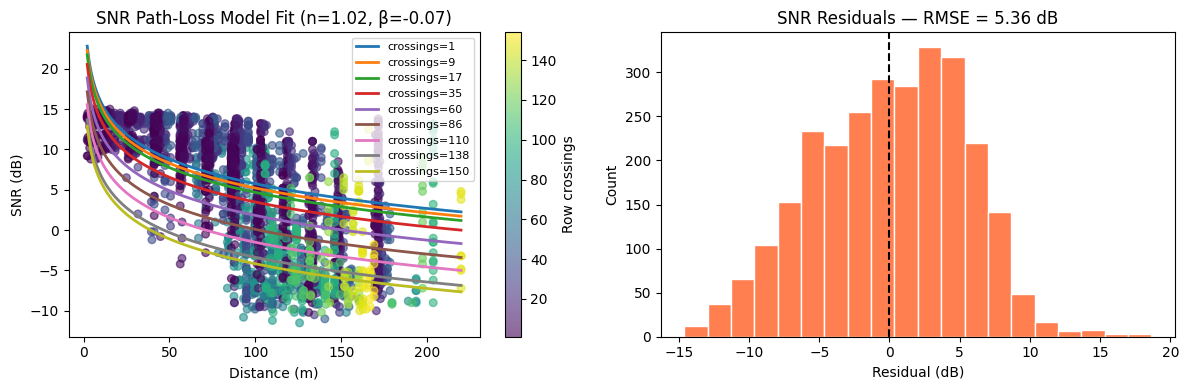

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

scatter = axes[0].scatter(
    valid['distance'], valid['snr'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for c in crossing_levels:
    pl_line = A_g_snr + n_log10_snr * np.log10(d_range) + beta_snr * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title(f'SNR Path-Loss Model Fit (n={-n_log10_snr/10:.2f}, β={beta_snr:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['snr_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'SNR Residuals — RMSE = {rmse_snr:.2f} dB')

plt.tight_layout()
plt.savefig('pathloss_fit_snr.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I — SNR residuals

Running Moran's I on 400 grid cell medians (SNR residuals)
=== Moran's I Test — SNR residuals ===
  Moran's I : 0.5560
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: proceed to GPR residual model for SNR.


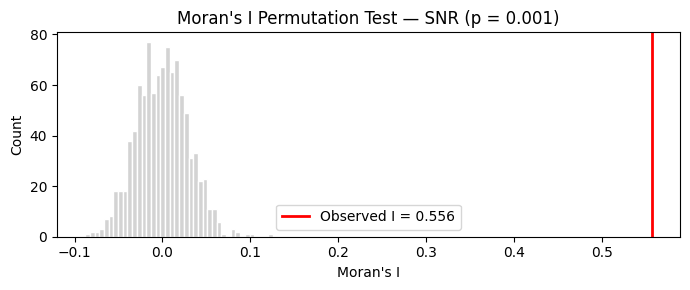

In [ ]:
cell_medians_snr = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('snr_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('snr_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians_snr)} grid cell medians (SNR residuals)")

coords_arr_snr = cell_medians_snr[['x_m', 'y_m']].values
residuals_arr_snr = cell_medians_snr['median_residual'].values

k_snr = min(5, len(cell_medians_snr) - 1)
w_snr = KNN.from_array(coords_arr_snr, k=k_snr)
w_snr.transform = 'r'

np.random.seed(42)
moran_snr = Moran(residuals_arr_snr, w_snr, permutations=999)

print("=== Moran's I Test — SNR residuals ===")
print(f"  Moran's I : {moran_snr.I:.4f}")
print(f"  p-value   : {moran_snr.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran_snr.p_sim < 0.05 and moran_snr.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model for SNR.')
else:
    print('No significant spatial autocorrelation in SNR residuals: GPR step may add little here.')

plt.figure(figsize=(7, 3))
plt.hist(moran_snr.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran_snr.I, color='red', lw=2, label=f'Observed I = {moran_snr.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test — SNR (p = {moran_snr.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i_snr.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 GPR — SNR (heteroscedastic)

Reuses the same coordinates (`X_gpr_scaled`), grid (`grid_df`, `xx`, `yy`), and CV folds (`groups`, `gkf`) as the RSSI GPR step — only the target changes to `snr_residual`. Everything is kept in separate `*_snr`-suffixed variables so nothing here overwrites the RSSI model or its results.

In [ ]:
y_gpr_snr = valid['snr_residual'].values.copy()

print(f'GPR target (SNR): {len(y_gpr_snr)} packets')
print(f'Residual range : {y_gpr_snr.min():.2f} to {y_gpr_snr.max():.2f} dB')
print(f'Residual mean  : {y_gpr_snr.mean():.2f} dB')

# Reuses X_gpr_scaled / scaler from the RSSI GPR step above — same physical
# coordinates (with the same jitter), so no need to re-fit the scaler.

GPR target (SNR): 2748 packets
Residual range : -14.61 to 18.64 dB
Residual mean  : -0.00 dB


In [ ]:
cell_noise_var_snr = valid.groupby('grid_label')['snr_residual'].var()
cell_counts_snr = valid.groupby('grid_label')['snr_residual'].count()

reliable_cells_snr = cell_counts_snr[cell_counts_snr >= min_reliable_n].index
global_median_var_snr = cell_noise_var_snr[reliable_cells_snr].median()
print(f'Global median cell variance (fallback, SNR): {global_median_var_snr:.3f} dB²')

valid['cell_noise_var_snr'] = valid['grid_label'].map(cell_noise_var_snr)
valid.loc[~valid['grid_label'].isin(reliable_cells_snr), 'cell_noise_var_snr'] = global_median_var_snr
valid['cell_noise_var_snr'] = valid['cell_noise_var_snr'].fillna(global_median_var_snr)

# Convert to standardized alpha (normalize_y divides by y_gpr_snr.std())
alpha_per_point_snr = valid['cell_noise_var_snr'].values / y_gpr_snr.var()

kernel_hetero_snr = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero_snr = GaussianProcessRegressor(
    kernel=kernel_hetero_snr,
    alpha=alpha_per_point_snr,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero_snr.fit(X_gpr_scaled, y_gpr_snr)

print(f'\nFitted SNR kernel: {gpr_hetero_snr.kernel_}')

Global median cell variance (fallback, SNR): 4.192 dB²

Fitted SNR kernel: 0.905**2 * Matern(length_scale=[0.447, 0.389], nu=0.5)


In [ ]:
fold_rmse_hetero_snr = []
for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr_snr, groups=groups):
    gp_cv_snr = GaussianProcessRegressor(
        kernel=kernel_hetero_snr,
        alpha=alpha_per_point_snr[train_idx],   # per-point alpha must be sliced per fold too
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv_snr.fit(X_gpr_scaled[train_idx], y_gpr_snr[train_idx])
    y_pred_snr_fold = gp_cv_snr.predict(X_gpr_scaled[test_idx])
    fold_rmse_hetero_snr.append(np.sqrt(mean_squared_error(y_gpr_snr[test_idx], y_pred_snr_fold)))

print(f'SNR heteroscedastic CV RMSE: {np.mean(fold_rmse_hetero_snr):.3f} ± {np.std(fold_rmse_hetero_snr):.3f} dB')
print(f'SNR path-loss-only RMSE    : {rmse_snr:.3f} dB (baseline, no GPR)')

SNR heteroscedastic CV RMSE: 4.233 ± 0.490 dB
SNR path-loss-only RMSE    : 5.360 dB (baseline, no GPR)


In [ ]:
joblib.dump(gpr_hetero_snr, 'gpr_hetero_snr_final_candidate.pkl')
joblib.dump(alpha_per_point_snr, 'alpha_hetero_snr_final.pkl')
print('Saved: gpr_hetero_snr_final_candidate.pkl, alpha_hetero_snr_final.pkl')

Saved: gpr_hetero_snr_final_candidate.pkl, alpha_hetero_snr_final.pkl


In [ ]:
X_pl_grid_snr = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['snr_pl_pred'] = X_pl_grid_snr @ coeffs_snr

gpr_mean_snr, gpr_std_snr = gpr_hetero_snr.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred_snr'] = gpr_mean_snr
grid_df['gpr_std_snr'] = gpr_std_snr
grid_df['snr_pred'] = grid_df['snr_pl_pred'] + grid_df['gpr_residual_pred_snr']

print(grid_df[['x_m', 'y_m', 'snr_pl_pred', 'gpr_residual_pred_snr', 'snr_pred', 'gpr_std_snr']].describe())

                x_m           y_m   snr_pl_pred  gpr_residual_pred_snr  \
count  23961.000000  23961.000000  23961.000000           23961.000000   
mean      -3.300000     53.600000      0.237573              -0.166448   
std       94.108287     84.870297      5.328576               3.227725   
min     -165.300000    -92.400000    -10.447258             -11.628822   
25%      -85.300000    -20.400000     -3.850306              -2.049609   
50%       -3.300000     53.600000      0.722016               0.200791   
75%       78.700000    127.600000      3.847257               1.541746   
max      158.700000    199.600000     27.140799               8.864407   

           snr_pred   gpr_std_snr  
count  23961.000000  23961.000000  
mean       0.071124      3.511617  
std        6.441391      1.139320  
min      -10.391946      0.607541  
25%       -5.376977      2.452075  
50%       -0.836003      3.624417  
75%        4.725991      4.738542  
max       18.423561      4.851791  


### SNR Heatmap + Uncertainty Map

Separate figure from the RSSI coverage heatmap above — own colorbar, own scale, own uncertainty panel. Not overlaid or combined with the RSSI plot.

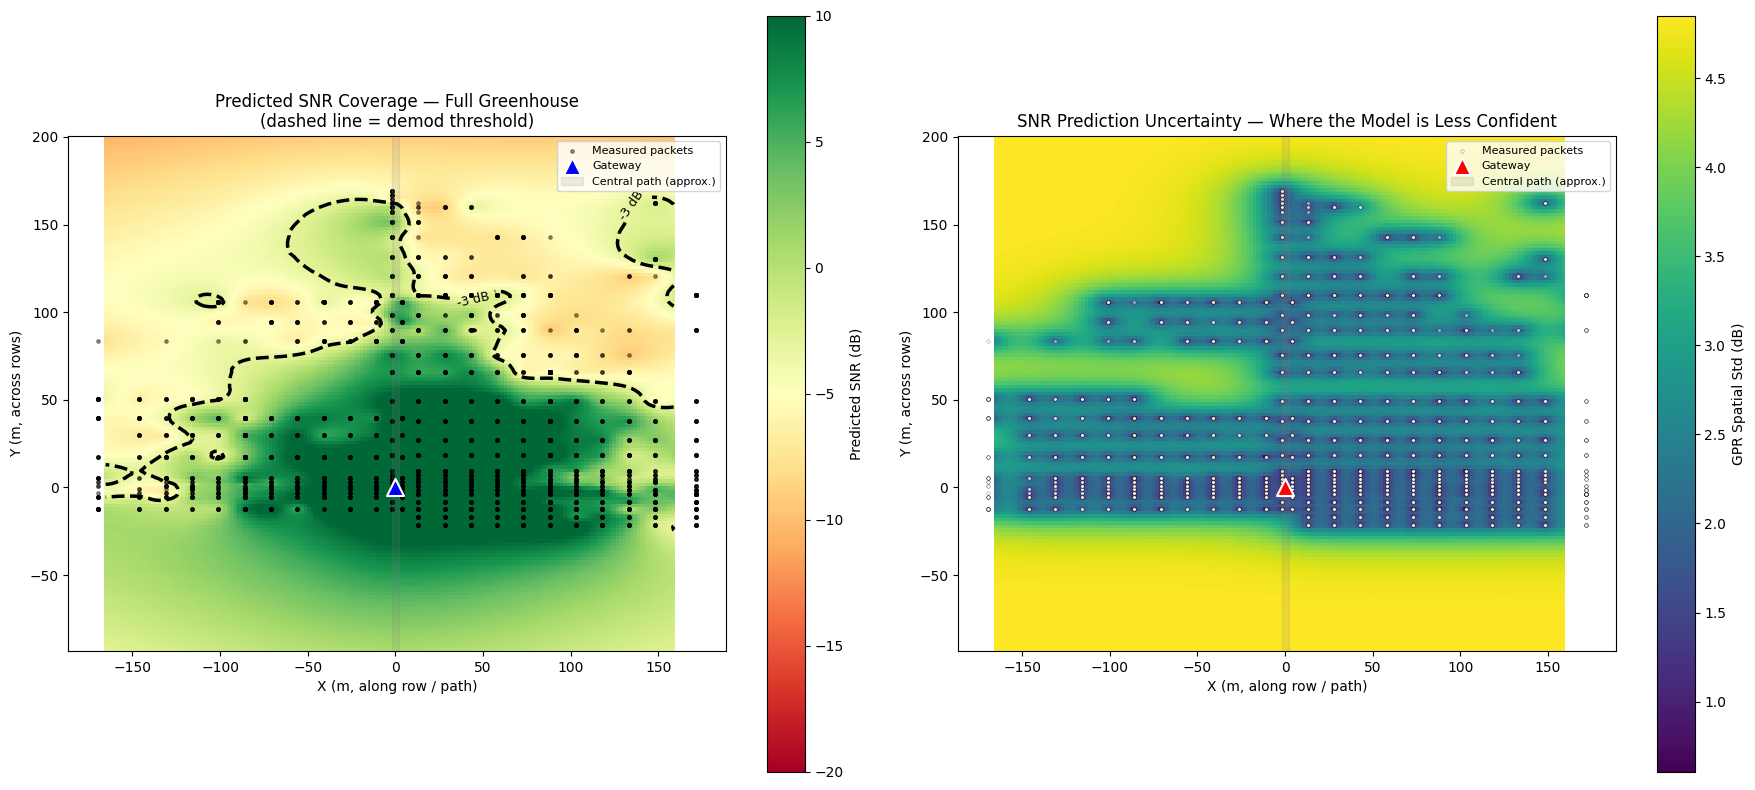

In [ ]:
import matplotlib.pyplot as plt

snr_grid = grid_df['snr_pred'].values.reshape(xx.shape)
snr_std_grid = grid_df['gpr_std_snr'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_db = - 3  # adjust to your target SF's SNR demodulation floor

# --- Panel 1: Predicted SNR coverage ---
im1 = axes[0].pcolormesh(xx, yy, snr_grid, cmap='RdYlGn', shading='auto',
                           vmin=-20, vmax=10)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted SNR (dB)')

contour1 = axes[0].contour(xx, yy, snr_grid, levels=[threshold_db],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_db} dB', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted SNR Coverage — Full Greenhouse\n(dashed line = demod threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: SNR prediction uncertainty (separate scale from RSSI) ---
im2 = axes[1].pcolormesh(xx, yy, snr_std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dB)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('SNR Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap_snr_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()

LOG. VS. LOG+ GPR

Model                           RMSE (dBm)    MAE (dBm)     R²      
--------------------------------------------------------------------
Path-Loss Only                  6.351         4.856         0.797   
Path-Loss + GPR (train)         3.447         2.286         0.940   
Path-Loss + GPR (CV, honest)    5.755         —             —       

Improvement (honest, CV-based): 0.596 dBm (9.4%)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


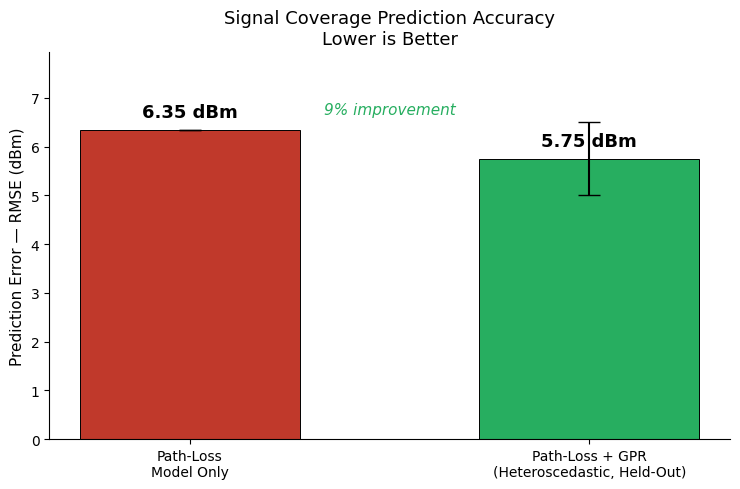

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STEP 1: Reuse your already-computed heteroscedastic CV results
# (no need to rerun — this was already validated separately)
# ============================================================
cv_rmse_mean = 5.755
cv_rmse_std = 0.742

# For the 3-panel scatter, you need pooled out-of-fold predictions.
# If you don't have cv_pred_residual from the heteroscedastic CV run saved,
# you'll need to regenerate it (same loop as before, but with alpha sliced
# per fold) — see note below.


# ============================================================
# STEP 2: Compute all prediction variants on the RSSI scale
# ============================================================
pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values

# Training-fit combined prediction using gpr_hetero (not gpr/kernel_final)
y_pred_train_hetero, _ = gpr_hetero.predict(X_gpr_scaled, return_std=True)
gpr_combined_rssi = pl_pred_rssi + y_pred_train_hetero

pl_rmse = rmse_full
pl_mae = mean_absolute_error(actual_rssi, pl_pred_rssi)
pl_r2 = r2_score(actual_rssi, pl_pred_rssi)

gpr_train_rmse = np.sqrt(mean_squared_error(actual_rssi, gpr_combined_rssi))
gpr_train_mae = mean_absolute_error(actual_rssi, gpr_combined_rssi)
gpr_train_r2 = r2_score(actual_rssi, gpr_combined_rssi)


# ============================================================
# STEP 3: Metrics table
# ============================================================
print(f"{'Model':<32}{'RMSE (dBm)':<14}{'MAE (dBm)':<14}{'R²':<8}")
print('-' * 68)
print(f"{'Path-Loss Only':<32}{pl_rmse:<14.3f}{pl_mae:<14.3f}{pl_r2:<8.3f}")
print(f"{'Path-Loss + GPR (train)':<32}{gpr_train_rmse:<14.3f}{gpr_train_mae:<14.3f}{gpr_train_r2:<8.3f}")
print(f"{'Path-Loss + GPR (CV, honest)':<32}{cv_rmse_mean:<14.3f}{'—':<14}{'—':<8}")
print()
print(f"Improvement (honest, CV-based): {pl_rmse - cv_rmse_mean:.3f} dBm "
      f"({100*(pl_rmse - cv_rmse_mean)/pl_rmse:.1f}%)")


# ============================================================
# STEP 4: Headline bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 5))

labels = ['Path-Loss\nModel Only', 'Path-Loss + GPR\n(Heteroscedastic, Held-Out)']
values = [pl_rmse, cv_rmse_mean]
errors = [0, cv_rmse_std]
colors = ['#c0392b', '#27ae60']

bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors,
               edgecolor='black', linewidth=0.7, width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.25, f'{val:.2f} dBm',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Prediction Error — RMSE (dBm)', fontsize=11)
ax.set_title('Signal Coverage Prediction Accuracy\nLower is Better', fontsize=13)
ax.set_ylim(0, max(values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

improvement_pct = 100 * (pl_rmse - cv_rmse_mean) / pl_rmse
ax.annotate(f'{improvement_pct:.0f}% improvement',
            xy=(0.5, max(values) * 1.05), ha='center', fontsize=11,
            style='italic', color='#27ae60')

plt.tight_layout()
plt.savefig('presentation_rmse_comparison_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import joblib

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

cv_pred_residual_hetero = np.full(len(y_gpr), np.nan)
fold_rmse_hetero = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],   # heteroscedastic — must slice per fold
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
    fold_pred = gp_cv.predict(X_gpr_scaled[test_idx])
    cv_pred_residual_hetero[test_idx] = fold_pred
    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], fold_pred)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero[-1]:.3f} dBm')

assert not np.isnan(cv_pred_residual_hetero).any(), "Some points were never in a test fold!"

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)


print(f'\nHeteroscedastic CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

joblib.dump(fold_rmse_hetero, 'cv_fold_rmse_hetero.pkl')
joblib.dump(cv_pred_residual_hetero, 'cv_pred_residual_hetero.pkl')
print('Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl')

  Fold complete: RMSE = 6.077 dBm
  Fold complete: RMSE = 4.875 dBm
  Fold complete: RMSE = 5.981 dBm
  Fold complete: RMSE = 5.737 dBm
  Fold complete: RMSE = 6.309 dBm

Heteroscedastic CV RMSE: 5.796 ± 0.496 dBm
Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import joblib

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

cv_pred_residual_hetero = np.full(len(y_gpr), np.nan)
cv_pred_std_hetero = np.full(len(y_gpr), np.nan)   # NEW — per-point predictive std
fold_rmse_hetero = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])

    fold_pred, fold_std = gp_cv.predict(X_gpr_scaled[test_idx], return_std=True)  # CHANGED
    cv_pred_residual_hetero[test_idx] = fold_pred
    cv_pred_std_hetero[test_idx] = fold_std   # NEW

    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], fold_pred)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero[-1]:.3f} dBm')

assert not np.isnan(cv_pred_residual_hetero).any(), "Some points were never in a test fold!"
assert not np.isnan(cv_pred_std_hetero).any(), "Some points never got a std estimate!"

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)

print(f'\nHeteroscedastic CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

joblib.dump(fold_rmse_hetero, 'cv_fold_rmse_hetero.pkl')
joblib.dump(cv_pred_residual_hetero, 'cv_pred_residual_hetero.pkl')
joblib.dump(cv_pred_std_hetero, 'cv_pred_std_hetero.pkl')  # NEW
print('Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl, cv_pred_std_hetero.pkl')

  Fold complete: RMSE = 6.077 dBm
  Fold complete: RMSE = 4.875 dBm
  Fold complete: RMSE = 5.981 dBm
  Fold complete: RMSE = 5.737 dBm
  Fold complete: RMSE = 6.309 dBm

Heteroscedastic CV RMSE: 5.796 ± 0.496 dBm
Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl, cv_pred_std_hetero.pkl


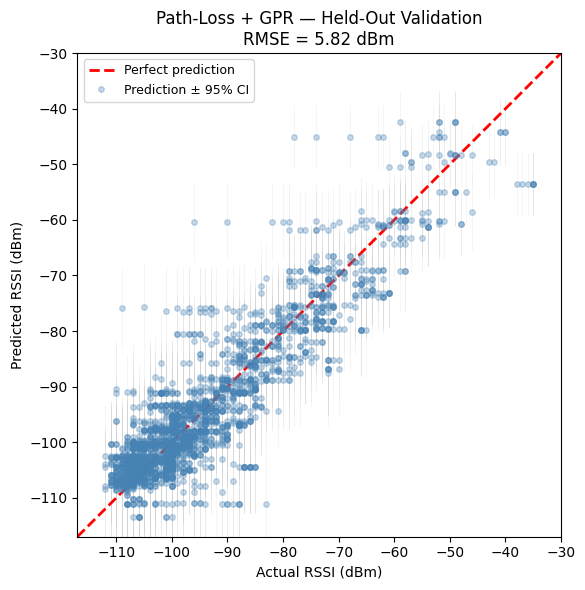

In [ ]:
import matplotlib.pyplot as plt

cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, ax = plt.subplots(figsize=(7, 6))

lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]

# Per-point error bars using each point's own predictive std (95% ≈ 1.96*std)
ax.errorbar(actual_rssi, cv_pred_rssi_hetero, yerr=1.96 * cv_pred_std_hetero,
            fmt='o', alpha=0.3, markersize=4, elinewidth=0.5, capsize=0,
            color='steelblue', ecolor='lightgray', label='Prediction ± 95% CI')

ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual RSSI (dBm)')
ax.set_ylabel('Predicted RSSI (dBm)')
ax.set_title(f'Path-Loss + GPR — Held-Out Validation\nRMSE = {cv_rmse_check:.2f} dBm')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('presentation_scatter_with_ci.png', dpi=200, bbox_inches='tight')
plt.show()

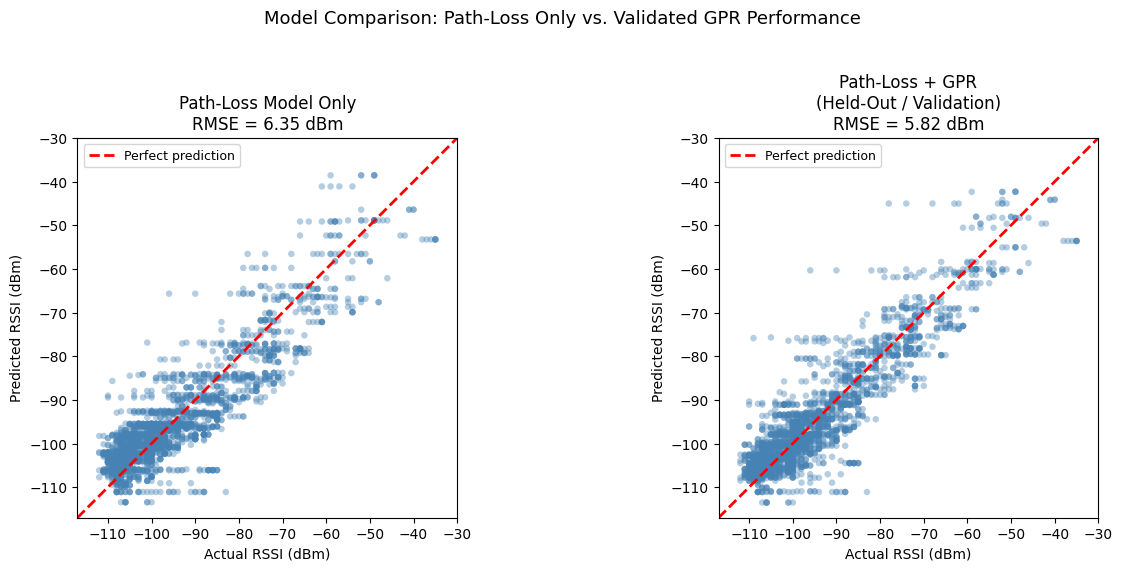

In [ ]:
import matplotlib.pyplot as plt

pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values
cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero

cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (cv_pred_rssi_hetero, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Path-Loss Only vs. Validated GPR Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('presentation_scatter_2panel_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

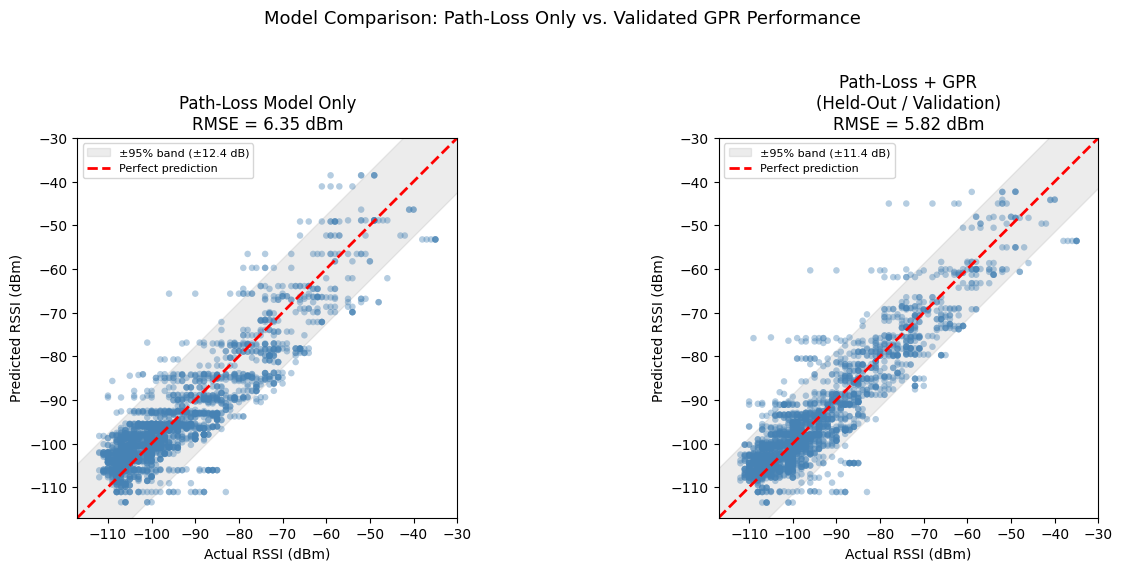

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values
cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (cv_pred_rssi_hetero, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    line_x = np.linspace(lims[0], lims[1], 100)

    # Shaded confidence band around the perfect-prediction line, using
    # this model's own RMSE as the margin (~95% band = ±1.96*RMSE)
    band_95 = 1.96 * rmse_val
    ax.fill_between(line_x, line_x - band_95, line_x + band_95,
                     color='gray', alpha=0.15, label=f'±95% band (±{band_95:.1f} dB)')

    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Path-Loss Only vs. Validated GPR Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('presentation_scatter_2panel_hetero.png', dpi=200, bbox_inches='tight')
plt.show()